In [1]:
import numpy as np
import pandas as pd


df = pd.read_csv('DE.csv')


indices_to_null = df.sample(n=50).index
df.loc[indices_to_null, 'attendance_percent'] = np.nan


outlier_indices = df.sample(n=10).index
df.loc[outlier_indices[0:5], 'exam_score'] = 150
df.loc[outlier_indices[5:10], 'previous_scores'] = -20


df.to_csv('DE_messy.csv', index=False)


In [2]:

import pandas as pd

# PREPROCESSING: CLEANING & FILTERING
df = pd.read_csv('dlp.csv')



# A. Cleaning (Handling Missing Values)
missing_before = df.isnull().sum().sum()
df_cleaned = df.ffill()
missing_after = df_cleaned.isnull().sum().sum()
print(f"Cleaning: Replaced {missing_before} missing values. Remaining: {missing_after}")

# B. Filtering (Removing impossible outliers)
df_filtered = df_cleaned[
    (df_cleaned['attendance_percent'] >= 0) & 
    (df_cleaned['attendance_percent'] <= 100) & 
    (df_cleaned['previous_scores'] >= 0) & 
    (df_cleaned['previous_scores'] <= 100) &
    (df_cleaned['exam_score'] >= 0) & 
    (df_cleaned['exam_score'] <= 100)
]

dropped_rows = len(df_cleaned) - len(df_filtered)
print(f"Filtering: Removed {dropped_rows} rows with impossible data/outliers.")
print(f"Final usable records: {len(df_filtered)}")


Cleaning: Replaced 50 missing values. Remaining: 0
Filtering: Removed 10 rows with impossible data/outliers.
Final usable records: 990


In [3]:
import pandas as pd

# DATA EXPLORATION (THE "SHOW-OFF" STEP)
print("--- Dataset Shape ---")
print(f"Rows: {df_filtered.shape[0]}, Columns: {df_filtered.shape[1]}")

print("\n--- Metadata & Data Types ---")
df_filtered.info()

print("\n--- Statistical Summary ---")
display(df_filtered.describe())

print("\n--- First 5 Records (The Head) ---")
display(df_filtered.head())

print("\n--- Last 5 Records (The Tail) ---")
display(df_filtered.tail())

--- Dataset Shape ---
Rows: 990, Columns: 6

--- Metadata & Data Types ---
<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          990 non-null    object 
 1   hours_studied       990 non-null    float64
 2   sleep_hours         990 non-null    float64
 3   attendance_percent  990 non-null    float64
 4   previous_scores     990 non-null    int64  
 5   exam_score          990 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 54.1+ KB

--- Statistical Summary ---


,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,990.000000,990.000000,990.000000,990.000000,990.000000
mean,6.333055,6.580909,74.086169,66.910101,33.901272
std,3.261468,1.513147,14.355035,15.536024,6.751822
min,0.585342,4.000000,48.676342,40.000000,16.324413
25%,3.500000,5.300000,61.507034,54.000000,29.500381
50%,6.122662,6.700000,73.700000,67.500000,34.158918
75%,9.161330,8.000000,86.809182,80.000000,38.726845
max,12.495508,9.000000,100.000000,95.000000,52.012703



--- First 5 Records (The Head) ---


,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,72.1,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3



--- Last 5 Records (The Tail) ---


,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
995,S996,10.499455,8.4,54.509981,47,37.866253
996,S997,2.453361,5.2,86.264243,87,30.839087
997,S998,11.402036,4.5,86.264243,67,39.998660
998,S999,11.730044,4.3,74.225196,77,39.087629
999,S1000,9.283366,5.4,68.910805,45,36.103778


In [17]:
import pandas as pd


df_filtered = df_filtered.copy()

# FUZZIFICATION TESTING
def fuzzify_score(score):
    # Low Score membership
    if score <= 20: low = 1.0
    elif 20 < score < 30: low = (30 - score) / 10.0
    else: low = 0.0

    # Medium Score membership
    if 25 <= score <= 35: medium = 1.0
    elif 20 < score < 25: medium = (score - 20) / 5.0
    elif 35 < score < 45: medium = (45 - score) / 10.0
    else: medium = 0.0

    # High Score membership
    if score >= 45: high = 1.0
    elif 35 < score < 45: high = (score - 35) / 10.0
    else: high = 0.0

    return [low, medium, high]

fuzzy_results = df_filtered['exam_score'].apply(fuzzify_score)
df_filtered[['Score_is_Low', 'Score_is_Medium', 'Score_is_High']] = pd.DataFrame(fuzzy_results.tolist(), index=df_filtered.index)

print("\n--- Fuzzification Complete ---")
print("Sample of the Fuzzified Score columns:")
print(df_filtered[['exam_score', 'Score_is_Low', 'Score_is_Medium', 'Score_is_High']].head(10))


--- Fuzzification Complete ---
Sample of the Fuzzified Score columns:
   exam_score  Score_is_Low  Score_is_Medium  Score_is_High
0        30.2          0.00             1.00           0.00
1        25.0          0.50             1.00           0.00
2        35.8          0.00             0.92           0.08
3        34.0          0.00             1.00           0.00
4        40.3          0.00             0.47           0.53
5        35.7          0.00             0.93           0.07
6        37.9          0.00             0.71           0.29
7        18.3          1.00             0.00           0.00
8        34.7          0.00             1.00           0.00
9        24.7          0.53             0.94           0.00


In [5]:
from sklearn.model_selection import train_test_split

# SPLITTING THE DATASET
print("--- Splitting Data ---")

# Define Features and Target
X = df_filtered.drop(columns=['student_id', 'exam_score'])
y = df_filtered['exam_score']

# Step A: Split off 70% for Training
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Step B: Split the 30% temporary pile into Validation (15%) and Testing (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training Set:   {len(X_train)} students")
print(f"Validation Set: {len(X_val)} students")
print(f"Testing Set:    {len(X_test)} students")

--- Splitting Data ---
Training Set:   693 students
Validation Set: 148 students
Testing Set:    149 students


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


features = ['hours_studied', 'attendance_percent', 'previous_scores', 'sleep_hours']
X_train_clean = X_train[features]


y_train_numeric = (y_train == 'Pass').astype(int)


dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)


dt_model.fit(X_train_clean, y_train_numeric)
rf_model.fit(X_train_clean, y_train_numeric)

print("--- Models Trained Successfully! ---")

--- Models Trained Successfully! ---


--- Generating Decision Tree Visualization ---


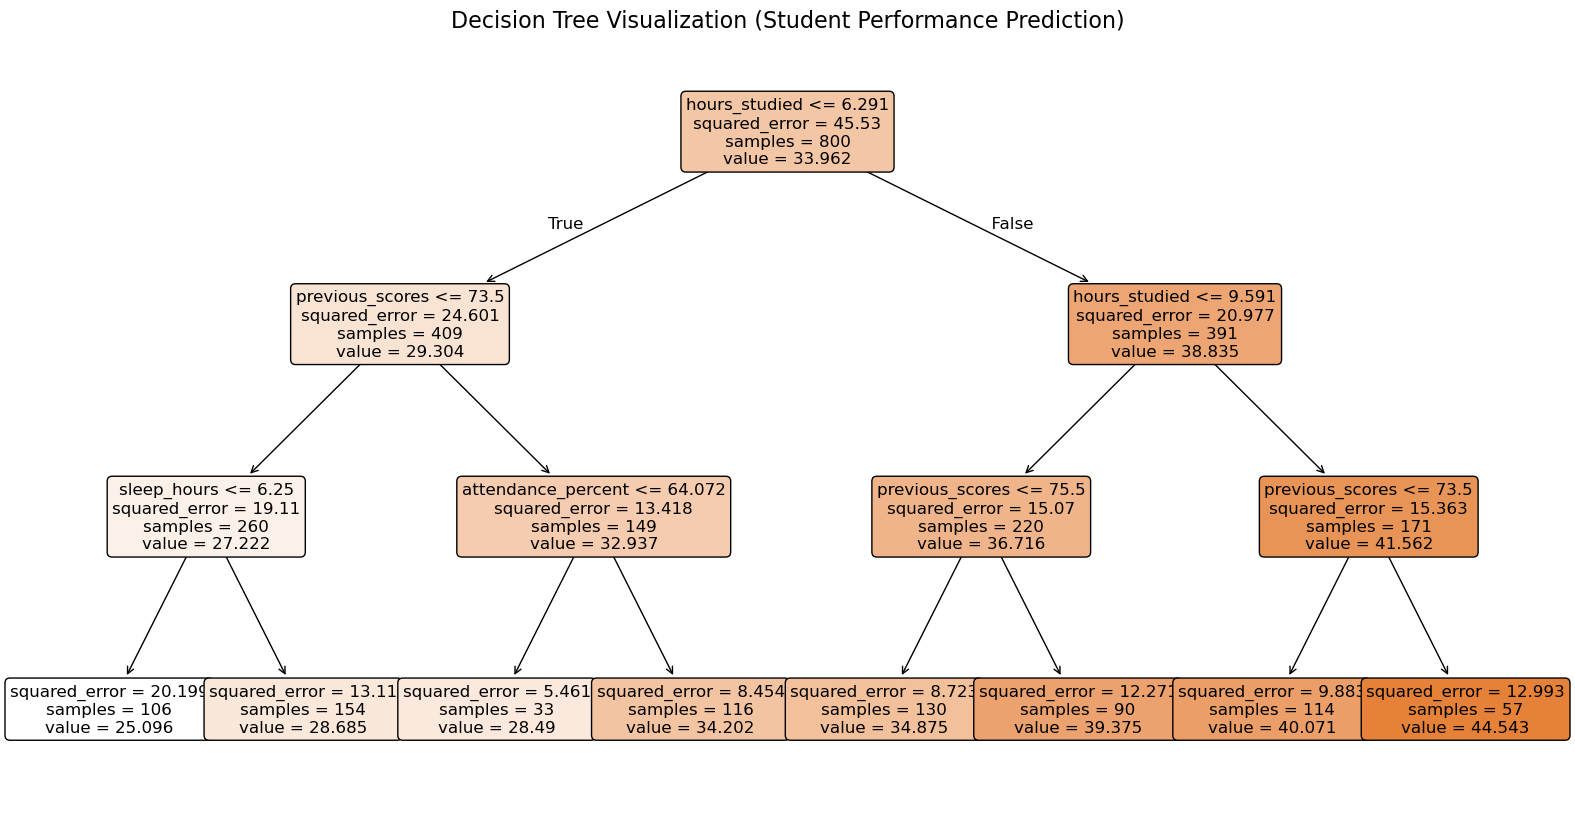

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Load and prepare data
try:
    df = pd.read_csv('DE.csv') 
    df_filtered = df.dropna().copy() 
except FileNotFoundError:
    print("Error: CSV file not found. Please check the file path.")

# Define features and target
features = ['hours_studied', 'attendance_percent', 'previous_scores', 'sleep_hours']
target = 'exam_score'

# Split data
X = df_filtered[features]
y = df_filtered[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train visualization model
dt_model_viz = DecisionTreeRegressor(random_state=42, max_depth=3) 
dt_model_viz.fit(X_train, y_train)

# Plot Decision Tree
print("--- Generating Decision Tree Visualization ---")
plt.figure(figsize=(20, 10))
plot_tree(dt_model_viz, 
          feature_names=features, 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.title('Decision Tree Visualization (Student Performance Prediction)', fontsize=16)
plt.show()

--- Training Models (Regression Mode) ---

[ Decision Tree ]
MAE: 2.28
R2 Score: 79.99%

[ Random Forest ]
MAE: 0.98
R2 Score: 95.00%


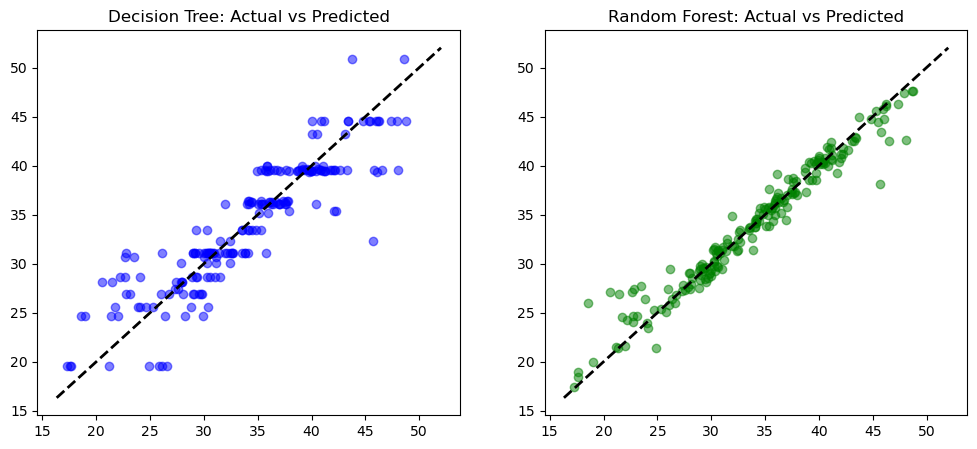

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


features = ['hours_studied', 'attendance_percent', 'previous_scores', 'sleep_hours']
target = 'exam_score'


X = df_filtered[features]
y = df_filtered[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Training Models (Regression Mode) ---")


dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)


dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


dt_predictions = dt_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)


print(f"\n[ Decision Tree ]")
print(f"MAE: {mean_absolute_error(y_test, dt_predictions):.2f}")
print(f"R2 Score: {r2_score(y_test, dt_predictions) * 100:.2f}%")

print(f"\n[ Random Forest ]")
print(f"MAE: {mean_absolute_error(y_test, rf_predictions):.2f}")
print(f"R2 Score: {r2_score(y_test, rf_predictions) * 100:.2f}%")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, dt_predictions, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.title('Decision Tree: Actual vs Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_predictions, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.title('Random Forest: Actual vs Predicted')
plt.show()


[ Decision Tree Report Card ]
Accuracy:  93.96%

[ Random Forest Report Card ]
Accuracy:  95.30%

--- Generating Confusion Matrices ---


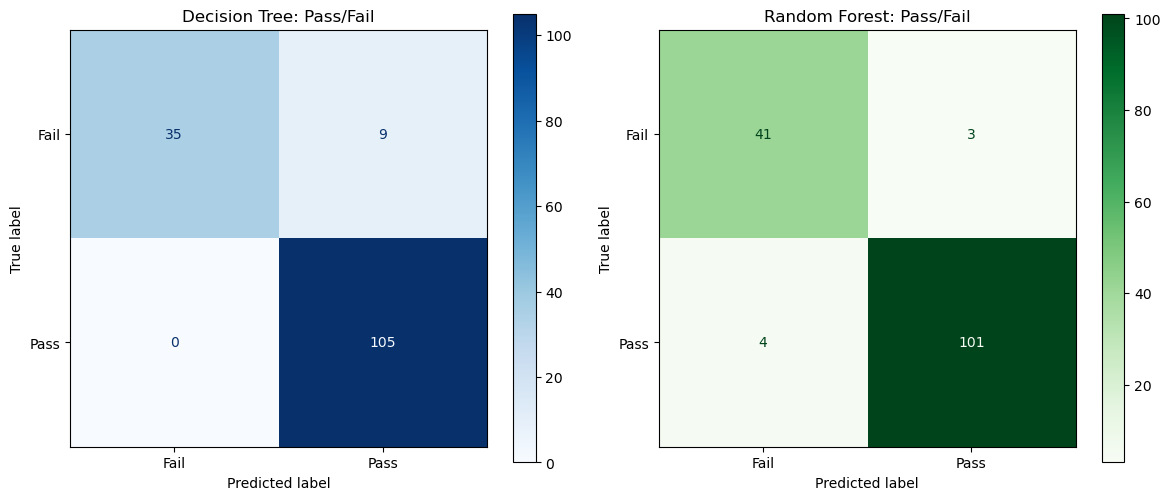

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



df_filtered.loc[:, 'Result'] = (df_filtered['exam_score'] >= 30).map({True: 'Pass', False: 'Fail'})

X = df_filtered[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
y = df_filtered['Result']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)


dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)


def print_report_card(name, y_true, y_pred):
    print(f"\n[ {name} Report Card ]")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred) * 100:.2f}%")

print_report_card("Decision Tree", y_test, dt_predictions)
print_report_card("Random Forest", y_test, rf_predictions)


print("\n--- Generating Confusion Matrices ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, dt_predictions, ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree: Pass/Fail')

ConfusionMatrixDisplay.from_predictions(y_test, rf_predictions, ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest: Pass/Fail')

plt.tight_layout()
plt.show()

--- Preparing Data for Neural Networks ---
--- Training Neural Networks ---


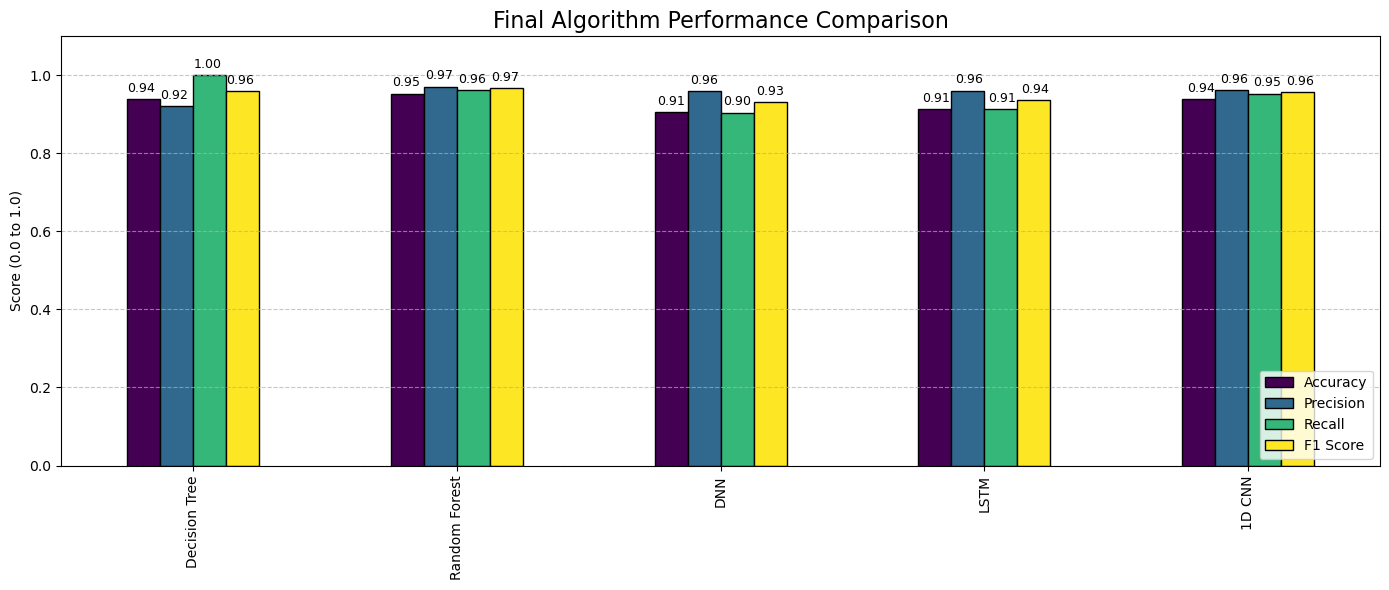

In [10]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


y_train_numeric = (y_train == 'Pass').astype(int)
y_test_numeric = (y_test == 'Pass').astype(int)

print("--- Preparing Data for Neural Networks ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_seq = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_seq = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))


dt_preds_numeric = (dt_predictions == 'Pass').astype(int)
rf_preds_numeric = (rf_predictions == 'Pass').astype(int)

print("--- Training Neural Networks ---")

# 1. DNN
dnn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.fit(X_train_scaled, y_train_numeric, epochs=20, batch_size=16, verbose=0)
dnn_predictions = (dnn_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()

# 2. LSTM
lstm_model = Sequential([
    Input(shape=(X_train_seq.shape[1], 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train_seq, y_train_numeric, epochs=40, batch_size=16, verbose=0)
lstm_predictions = (lstm_model.predict(X_test_seq, verbose=0) > 0.5).astype(int).flatten()

# 3. 1D CNN
cnn_model = Sequential([
    Input(shape=(X_train_seq.shape[1], 1)),
    Conv1D(filters=32, kernel_size=2, activation='relu'),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_seq, y_train_numeric, epochs=20, batch_size=16, verbose=0)
cnn_predictions = (cnn_model.predict(X_test_seq, verbose=0) > 0.5).astype(int).flatten()

# Final Comparison
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

scores = {
    'Decision Tree': get_metrics(y_test_numeric, dt_preds_numeric),
    'Random Forest': get_metrics(y_test_numeric, rf_preds_numeric),
    'DNN': get_metrics(y_test_numeric, dnn_predictions),
    'LSTM': get_metrics(y_test_numeric, lstm_predictions),
    '1D CNN': get_metrics(y_test_numeric, cnn_predictions)
}

df_scores = pd.DataFrame(scores, index=['Accuracy', 'Precision', 'Recall', 'F1 Score']).T
ax = df_scores.plot(kind='bar', figsize=(14, 6), colormap='viridis', edgecolor='black')
plt.title('Final Algorithm Performance Comparison', fontsize=16)
plt.ylabel('Score (0.0 to 1.0)')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() * 1.005, p.get_height() * 1.02), fontsize=9)

plt.tight_layout()
plt.show()

--- Generating True Predictive Alignment Chart ---


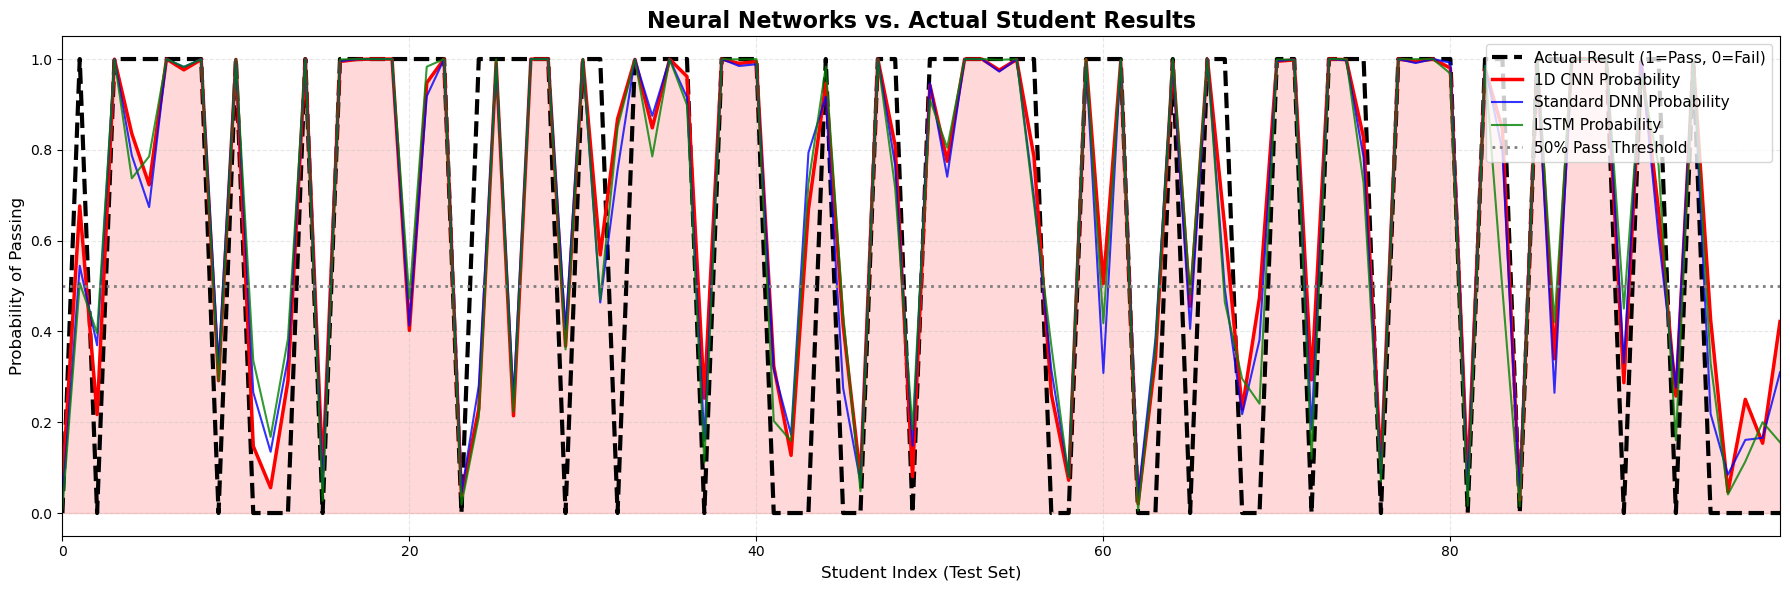

In [11]:
import matplotlib.pyplot as plt

print("--- Generating True Predictive Alignment Chart ---")

students_to_plot = 100
actual_result = y_test_numeric[:students_to_plot]

cnn_probs = cnn_model.predict(X_test_seq[:students_to_plot], verbose=0).flatten()
dnn_probs = dnn_model.predict(X_test_scaled[:students_to_plot], verbose=0).flatten()
lstm_probs = lstm_model.predict(X_test_seq[:students_to_plot], verbose=0).flatten()

plt.figure(figsize=(18, 6))

plt.plot(range(students_to_plot), actual_result, label='Actual Result (1=Pass, 0=Fail)',
         color='black', linewidth=3, linestyle='--')

plt.plot(range(students_to_plot), cnn_probs, label='1D CNN Probability', color='red', linewidth=2.5)
plt.fill_between(range(students_to_plot), cnn_probs, alpha=0.15, color='red')

plt.plot(range(students_to_plot), dnn_probs, label='Standard DNN Probability', color='blue', linewidth=1.5, alpha=0.8)
plt.plot(range(students_to_plot), lstm_probs, label='LSTM Probability', color='green', linewidth=1.5, alpha=0.8)

plt.title('Neural Networks vs. Actual Student Results', fontsize=16, fontweight='bold')
plt.ylabel('Probability of Passing', fontsize=12)
plt.xlabel('Student Index (Test Set)', fontsize=12)

plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=2, label='50% Pass Threshold')

plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, students_to_plot - 1)
plt.tight_layout()
plt.show()

In [14]:
pip install scikit-fuzzy

Note: you may need to restart the kernel to use updated packages.


--- Running K-Means Clustering (Stand-alone) ---


C:\Users\RePack\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


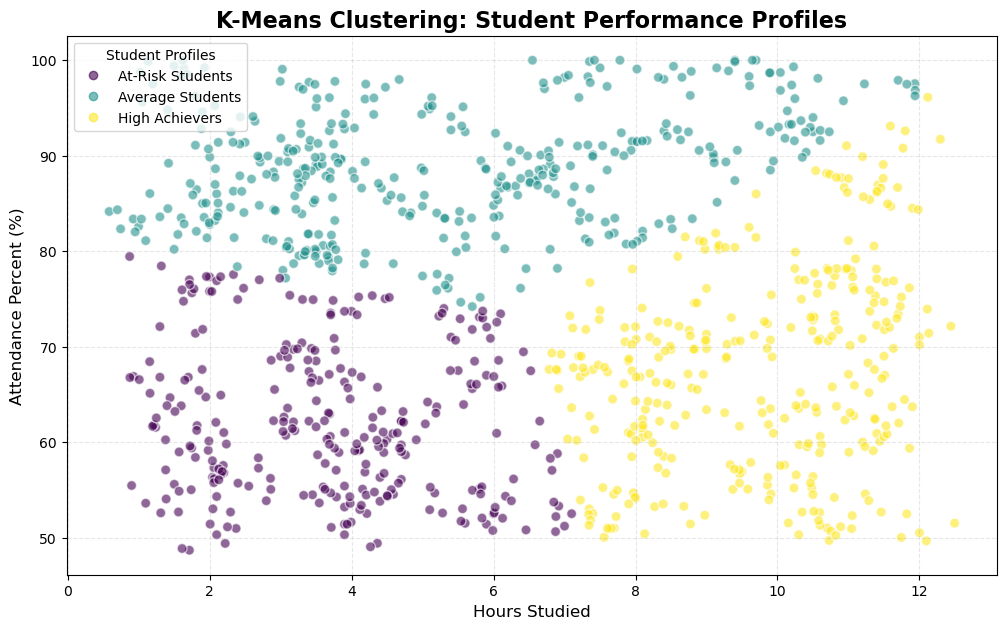


--- Done! ---


In [5]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("--- Running K-Means Clustering (Stand-alone) ---")

df = pd.read_csv('dlp.csv') 
df_cleaned = df.ffill()

df_filtered = df_cleaned[
    (df_cleaned['attendance_percent'] >= 0) & (df_cleaned['attendance_percent'] <= 100) & 
    (df_cleaned['hours_studied'] >= 0) & (df_cleaned['previous_scores'] >= 0)
]

features = ['hours_studied', 'attendance_percent']
X = df_filtered[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_filtered['hours_studied'], df_filtered['attendance_percent'],
            c=clusters, cmap='viridis', s=50, alpha=0.6, edgecolors='w')

plt.title('K-Means Clustering: Student Performance Profiles', fontsize=16, fontweight='bold')
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Attendance Percent (%)', fontsize=12)

legend_labels = ["At-Risk Students", "Average Students", "High Achievers"]
legend1 = plt.legend(handles=scatter.legend_elements()[0],
                    labels=legend_labels,
                    title="Student Profiles",
                    loc="upper left")

plt.grid(True, alpha=0.3, linestyle='--')
plt.show()

print("\n--- Done! ---")

--- Running Fuzzy C-Means Clustering ---


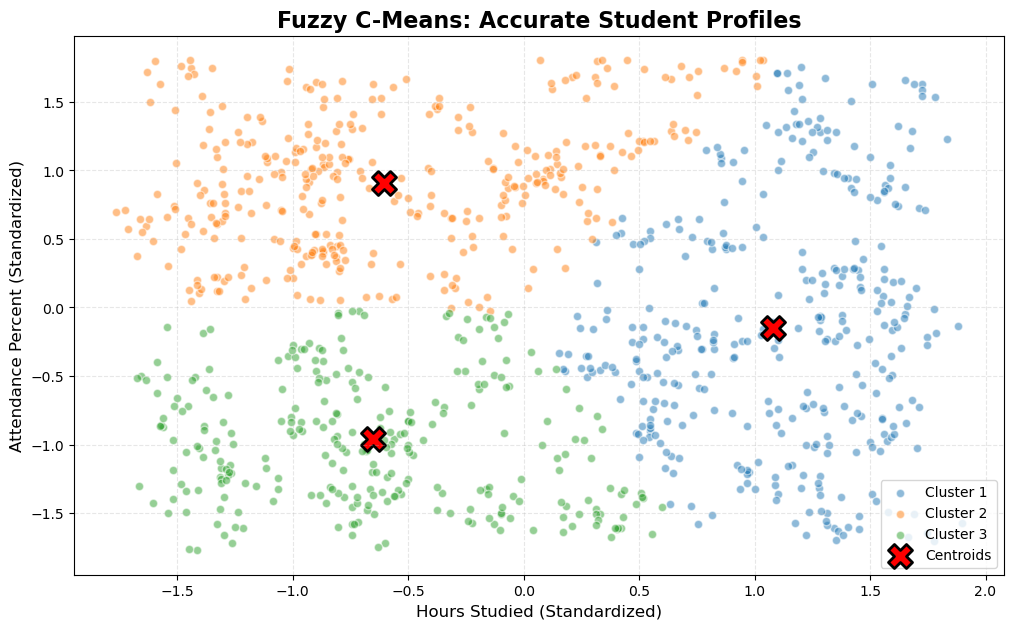

Fuzzy Partition Coefficient (FPC): 0.6430


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from sklearn.preprocessing import StandardScaler

print("--- Running Fuzzy C-Means Clustering ---")

df = pd.read_csv('dlp.csv') 
df_cleaned = df.ffill()
df_filtered = df_cleaned[
    (df_cleaned['attendance_percent'] >= 0) & (df_cleaned['attendance_percent'] <= 100) & 
    (df_cleaned['hours_studied'] >= 0)
].copy()

features = ['hours_studied', 'attendance_percent']
X = df_filtered[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

data = X_scaled.T
n_clusters = 3

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data, n_clusters, 2, error=0.005, maxiter=1000, init=None)

cluster_membership = np.argmax(u, axis=0)

plt.figure(figsize=(12, 7))

for j in range(n_clusters):
    plt.scatter(X_scaled[cluster_membership == j, 0], 
                X_scaled[cluster_membership == j, 1], 
                label=f'Cluster {j+1}', alpha=0.5, edgecolors='w')

plt.scatter(cntr[:, 0], cntr[:, 1], marker='X', s=300, c='red', 
            label='Centroids', edgecolors='black', linewidth=2)

plt.title('Fuzzy C-Means: Accurate Student Profiles', fontsize=16, fontweight='bold')
plt.xlabel('Hours Studied (Standardized)', fontsize=12)
plt.ylabel('Attendance Percent (Standardized)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.show()

print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")

--- Running Graph Neural Network (GNN) ---
Epoch 0: Loss 0.3194
Epoch 20: Loss 0.0624
Epoch 40: Loss 0.0569
Epoch 60: Loss 0.0439
Epoch 80: Loss 0.0489
Epoch 100: Loss 0.0525

--- GNN Training Completed! ---


In [11]:
!pip install torch torchvision torchaudio
!pip install torch-geometric

In [15]:
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

print("--- Running GNN (Knowledge Sharing Scenario) ---")


edge_index = torch.tensor([
    [0, 1, 1, 0, 1, 2, 2, 1, 0, 1, 2],
    [1, 0, 0, 1, 2, 1, 1, 2, 0, 1, 2]
], dtype=torch.long)


x = torch.tensor([
    [1.0], 
    [5.0], 
    [2.0]  
], dtype=torch.float)


y = torch.tensor([1, 1, 1], dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)


class StudentGNN(torch.nn.Module):
    def __init__(self):
        super(StudentGNN, self).__init__()
        self.conv1 = GCNConv(1, 4) 
        self.conv2 = GCNConv(4, 2) 
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
     
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
       
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)
model = StudentGNN()
model.eval()
out = model(data)
predictions = out.argmax(dim=1)

print("Original Features (Knowledge):")
print(x.numpy())
print("\nGNN Latent State (Log Probabilities):")
print(out.detach().numpy())


print("\n--- GNN Scenario Applied Successfully ---")

--- Running GNN (Knowledge Sharing Scenario) ---
Original Features (Knowledge):
[[1.]
 [5.]
 [2.]]

GNN Latent State (Log Probabilities):
[[-0.9881332  -0.46564683]
 [-1.2011381  -0.3578923 ]
 [-1.0041345  -0.45627686]]

--- GNN Scenario Applied Successfully ---


--- Running GNN on Student Data ---


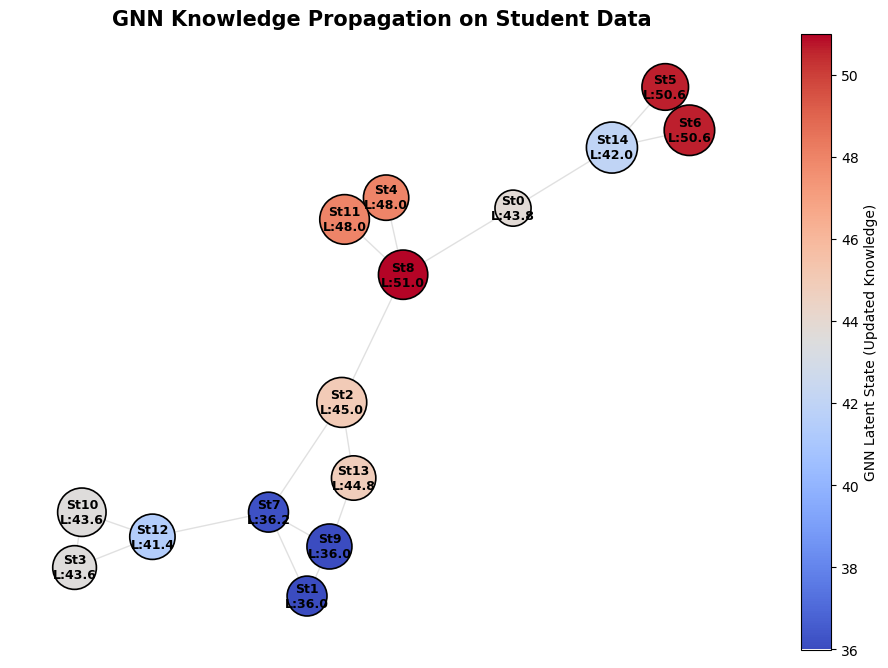

--- GNN Visualization Completed ---


In [19]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

print("--- Running GNN on Student Data ---")

df = pd.read_csv('dlp.csv') 
df_cleaned = df.ffill()
df_sample = df_cleaned.head(15).copy()

features_cols = ['hours_studied', 'attendance_percent']
X_raw = df_sample[features_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

adj = NearestNeighbors(n_neighbors=3).fit(X_scaled)
distances, indices = adj.kneighbors(X_scaled)

num_students = len(df_sample)
tilde_A = np.eye(num_students) 
for i, neighbors in enumerate(indices):
    for neighbor in neighbors:
        tilde_A[i, neighbor] = 1

X_knowledge = df_sample[['previous_scores']].values
W = 0.2 
aggregated_values = np.matmul(tilde_A, X_knowledge) 
latent_state = aggregated_values * W 

fig, ax = plt.subplots(figsize=(12, 8)) 
G = nx.Graph()

for i in range(num_students):
    G.add_node(i, orig=X_knowledge[i][0], latent=latent_state[i][0])

for i, neighbors in enumerate(indices):
    for neighbor in neighbors:
        if i != neighbor:
            G.add_edge(i, neighbor)

pos = nx.spring_layout(G, seed=42)
orig_vals = np.array([G.nodes[i]['orig'] for i in G.nodes])
latent_vals = np.array([G.nodes[i]['latent'] for i in G.nodes])

nodes = nx.draw_networkx_nodes(G, pos, node_size=orig_vals*15, 
                               node_color=latent_vals, cmap=plt.cm.coolwarm,
                               edgecolors='black', linewidths=1.2, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#cccccc', alpha=0.6, ax=ax)

labels = {i: f"St{i}\nL:{G.nodes[i]['latent']:.1f}" for i in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold', ax=ax)

sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, 
                           norm=plt.Normalize(vmin=min(latent_vals), vmax=max(latent_vals)))
sm.set_array([])
fig.colorbar(sm, ax=ax, label='GNN Latent State (Updated Knowledge)')

plt.title("GNN Knowledge Propagation on Student Data", fontsize=15, fontweight='bold')
plt.axis('off')
plt.show()

print("--- GNN Visualization Completed ---")

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# ── 1. تحميل البيانات ──────────────────────────────────
df = pd.read_csv('dlp.csv')
df = df.ffill()
df = df[
    (df['attendance_percent'] >= 0) & (df['attendance_percent'] <= 100) &
    (df['previous_scores'] >= 0) & (df['previous_scores'] <= 100) &
    (df['exam_score'] >= 0) & (df['exam_score'] <= 100)
].copy().reset_index(drop=True)

# ── 2. الـ Features والـ Target ──────────────────────────
feature_cols = ['hours_studied', 'attendance_percent', 'previous_scores', 'sleep_hours']
scaler = StandardScaler()
X_np = scaler.fit_transform(df[feature_cols].values)
y_np = df['exam_score'].values.astype(np.float32)

# ── 3. بناء الـ Graph (المنطق: نفس الـ class = edge) ──
# كل 5 طلاب في كلاس واحد
CLASS_SIZE = 5
n = len(df)
src, dst = [], []

for i in range(n):
    class_id = i // CLASS_SIZE
    for j in range(class_id * CLASS_SIZE, min((class_id + 1) * CLASS_SIZE, n)):
        if i != j:
            src.append(i)
            dst.append(j)

edge_index = torch.tensor([src, dst], dtype=torch.long)
x = torch.tensor(X_np, dtype=torch.float)
y = torch.tensor(y_np, dtype=torch.float)

data = Data(x=x, edge_index=edge_index, y=y)

# ── 4. تقسيم train/test ────────────────────────────────
n_train = int(0.8 * n)
train_mask = torch.zeros(n, dtype=torch.bool)
test_mask  = torch.zeros(n, dtype=torch.bool)
train_mask[:n_train] = True
test_mask[n_train:]  = True

data.train_mask = train_mask
data.test_mask  = test_mask

# ── 5. تعريف الموديل ──────────────────────────────────
class StudentGCN(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 32)
        self.conv2 = GCNConv(32, 16)
        self.out   = torch.nn.Linear(16, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        return self.out(x).squeeze()

model = StudentGCN(in_channels=len(feature_cols))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

# ── 6. Training Loop ──────────────────────────────────
print("--- Training GCN ---")
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    out  = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss.item():.4f}")

# ── 7. التقييم ────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds = model(data)[data.test_mask].numpy()
    actual = data.y[data.test_mask].numpy()

mae = mean_absolute_error(actual, preds)
r2  = r2_score(actual, preds)

print(f"\n[ GCN Results ]")
print(f"MAE:      {mae:.2f}")
print(f"R² Score: {r2 * 100:.2f}%")

--- Training GCN ---
Epoch  10 | Train Loss: 1112.9014
Epoch  20 | Train Loss: 897.7853
Epoch  30 | Train Loss: 433.4645
Epoch  40 | Train Loss: 73.5389
Epoch  50 | Train Loss: 88.0436
Epoch  60 | Train Loss: 57.3276
Epoch  70 | Train Loss: 52.0197
Epoch  80 | Train Loss: 48.3179
Epoch  90 | Train Loss: 45.6956
Epoch 100 | Train Loss: 44.8080

[ GCN Results ]
MAE:      4.82
R² Score: 0.28%


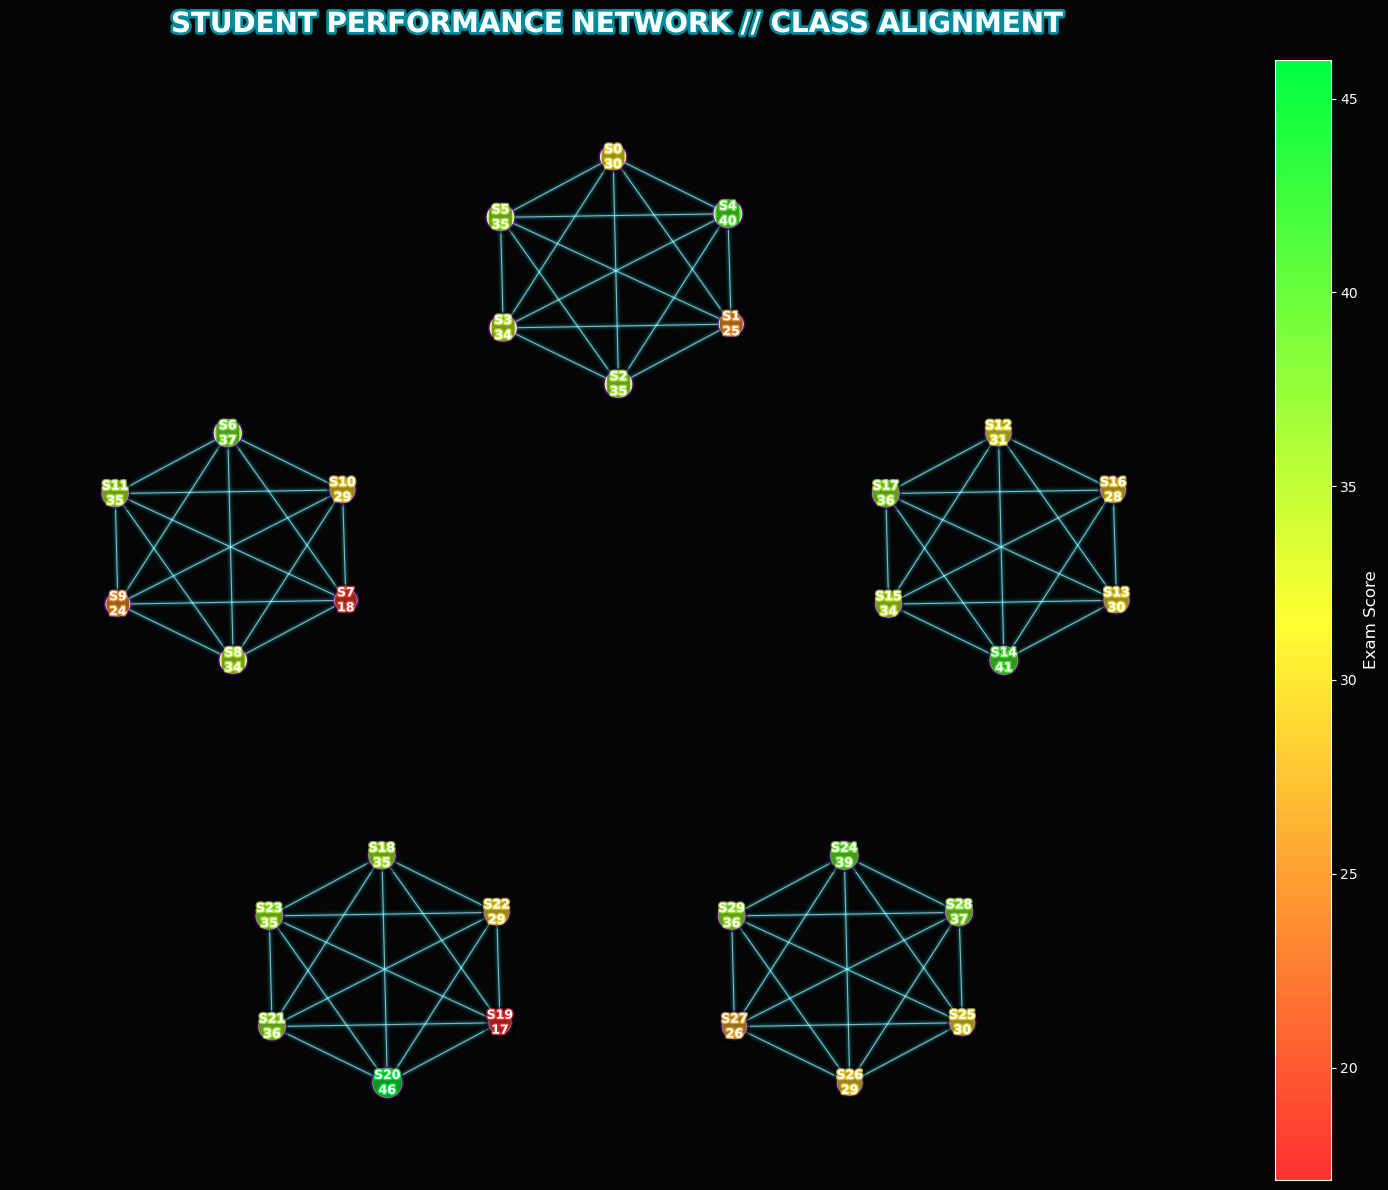

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np
import pandas as pd


try:
    data_to_use = df_filtered if 'df_filtered' in locals() else df
except NameError:
    try:
        data_to_use = pd.read_csv('DE.csv')
    except FileNotFoundError:

        print("Warning: 'DE.csv' not found. Generating synthetic data for visualization.")
        np.random.seed(42)
        N_TOTAL = 100
        data_to_use = pd.DataFrame({
            'hours_studied': np.random.randint(1, 10, N_TOTAL),
            'attendance_percent': np.random.randint(60, 100, N_TOTAL),
            'previous_scores': np.random.randint(40, 100, N_TOTAL),
            'sleep_hours': np.random.randint(4, 9, N_TOTAL),
            'exam_score': np.random.randint(30, 100, N_TOTAL)
        })


data_to_use = data_to_use.dropna(subset=['hours_studied', 'attendance_percent', 'previous_scores', 'sleep_hours', 'exam_score'])

n_show = 30  
node_scores = data_to_use['exam_score'].values[:n_show]


np.random.seed(42)
classes_for_show = np.repeat([0, 1, 2, 3, 4], 6)


G = nx.Graph()
G.add_nodes_from(range(n_show))
for i in range(n_show):
    for j in range(i + 1, n_show):
        if classes_for_show[i] == classes_for_show[j]:
            G.add_edge(i, j)


class_centers = {
    0: (0, 2.5),    
    1: (-2, 0.8),  
    2: (2, 0.8),   
    3: (-1.2, -1.8), 
    4: (1.2, -1.8)   
}

pos = {}
for class_id in range(5):
    nodes_in_class = [i for i in range(n_show) if classes_for_show[i] == class_id]
    subgraph = G.subgraph(nodes_in_class)
    center = class_centers[class_id]
    sub_pos = nx.spring_layout(subgraph, center=center, scale=0.7, seed=42)
    pos.update(sub_pos)


plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#050505')
ax.set_facecolor('#050505')


neon_green = '#00FF41'   
neon_red = '#FF3131'     
neon_blue = '#00E5FF'   
neon_purple = '#9400D3' 


cmap_neon = mcolors.LinearSegmentedColormap.from_list("neon_cmap", [neon_red, "#FFFF33", neon_green])


norm = plt.Normalize(vmin=node_scores.min(), vmax=node_scores.max())
node_colors = [cmap_neon(norm(score)) for score in node_scores]
node_sizes = (node_scores**1.5) * 0.8 + 200


for i in range(3, 0, -1):
    nx.draw_networkx_edges(G, pos, edge_color=neon_blue, 
                           alpha=0.15/i, width=1.0 + i*1.5, ax=ax, style='solid')
nx.draw_networkx_edges(G, pos, edge_color='#FFFFFF', alpha=0.6, width=0.8, ax=ax)


for i in range(1, 4):
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes + i*15, 
                           node_color=node_colors, alpha=0.1/i, ax=ax)

nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                               node_size=node_sizes, 
                               edgecolors='#FFFFFF', linewidths=0.5, ax=ax)


nodes.set_path_effects([path_effects.withStroke(linewidth=3, foreground=neon_purple, alpha=0.5)])


labels = {i: f"S{i}\n{int(node_scores[i])}" for i in range(n_show)}
for i, (node, (x, y)) in enumerate(pos.items()):
    color = node_colors[i]
    txt = ax.text(x, y, labels[node], color='#FFFFFF', 
                  fontsize=9, fontweight='bold',
                  ha='center', va='center',
                  bbox=dict(facecolor='black', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.2'))
    
    txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground=color, alpha=0.7)])


ax.set_title("STUDENT PERFORMANCE NETWORK // CLASS ALIGNMENT", 
             color='#FFFFFF', fontsize=20, fontweight='bold', pad=20)
ax.title.set_path_effects([path_effects.withStroke(linewidth=4, foreground=neon_blue, alpha=0.6)])


sm = plt.cm.ScalarMappable(cmap=cmap_neon, norm=norm)
cb = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('Exam Score', color='#FFFFFF', fontsize=12)
cb.ax.yaxis.set_tick_params(color='#FFFFFF')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#FFFFFF')
cb.outline.set_edgecolor('#FFFFFF')


ax.grid(True, color='#111111', linestyle='--', linewidth=0.5)

ax.axis('off')
plt.tight_layout()
plt.show()